In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("Heart_Disease_Responses.csv")

In [38]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level (mg/dL),Heart Rate (bpm),Chest Pain Type,Exercise Frequency,Do you smoke?,Family history of heart disease?,Do you have heart disease?
0,25,Male,100.0,172.0,92.0,Asymptomatic,Regular,No,Yes,No
1,29,Female,105.0,168.2,94.6,Typical Angina,Sometimes,No,No,No
2,33,Male,109.7,183.9,96.2,Atypical Angina,Never,No,No,No
3,37,Female,114.1,179.1,96.1,Non-anginal Pain,Sometimes,No,Yes,No
4,41,Male,117.9,194.0,94.2,Asymptomatic,Sometimes,No,No,No


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               2000 non-null   int64  
 1   Gender                            2000 non-null   object 
 2   Blood Pressure                    1980 non-null   float64
 3   Cholesterol Level (mg/dL)         1982 non-null   float64
 4   Heart Rate (bpm)                  1985 non-null   float64
 5   Chest Pain Type                   2000 non-null   object 
 6   Exercise Frequency                2000 non-null   object 
 7   Do you smoke?                     2000 non-null   object 
 8   Family history of heart disease?  2000 non-null   object 
 9   Do you have heart disease?        2000 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 156.4+ KB


### Check missing values

In [40]:
df.isnull().sum()

Age                                  0
Gender                               0
Blood Pressure                      20
Cholesterol Level (mg/dL)           18
Heart Rate (bpm)                    15
Chest Pain Type                      0
Exercise Frequency                   0
Do you smoke?                        0
Family history of heart disease?     0
Do you have heart disease?           0
dtype: int64

### Handle missing values

In [41]:
bp_mean = df['Blood Pressure'].mean()
ch_mean = df['Cholesterol Level (mg/dL)'].mean()
hr_mean = df['Heart Rate (bpm)'].mean()

In [42]:
df['Blood Pressure'] = df['Blood Pressure'].fillna(bp_mean)
df['Cholesterol Level (mg/dL)'] = df['Cholesterol Level (mg/dL)'].fillna(ch_mean)
df['Heart Rate (bpm)'] = df['Heart Rate (bpm)'].fillna(hr_mean)

In [43]:
df.isnull().sum()

Age                                 0
Gender                              0
Blood Pressure                      0
Cholesterol Level (mg/dL)           0
Heart Rate (bpm)                    0
Chest Pain Type                     0
Exercise Frequency                  0
Do you smoke?                       0
Family history of heart disease?    0
Do you have heart disease?          0
dtype: int64

### Check duplicates

In [44]:
duplicates = df.duplicated().sum()
duplicates

np.int64(32)

In [45]:
df = df.drop_duplicates()

In [46]:
df.shape

(1968, 10)

### Detect outliers - box plot

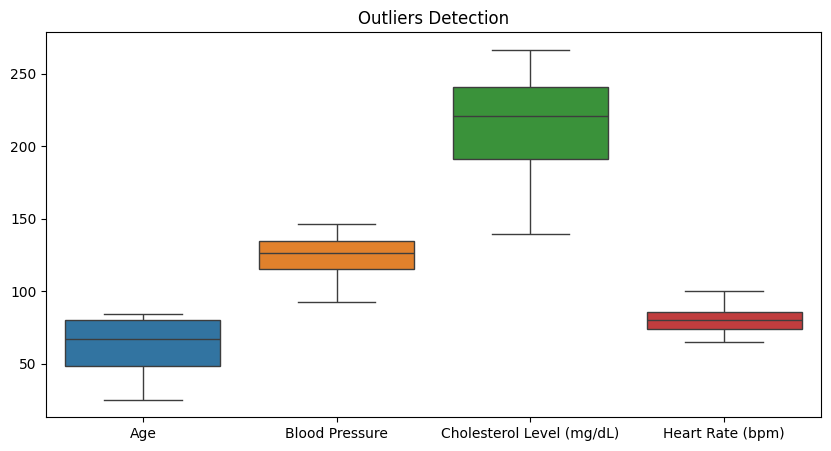

In [47]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Outliers Detection")
plt.show()

No Outliers Detected

### save cleaned csv

In [48]:
df.to_csv("cleaned_heart_data.csv", index=False)